# 20 – Feature Selection

This notebook performs systematic feature selection on the encoded/scaled datasets produced earlier. We use filter (variance, correlation) and wrapper (RFE) methods, selecting features based on validation performance while avoiding leakage.

- Inputs: `12_x_train.csv`, `12_y_train.csv`, `12_x_val.csv`, `12_y_val.csv`, `12_x_test.csv`.
- Outputs: `20_x_train.csv`, `20_y_train.csv`, `20_x_val.csv`, `20_y_val.csv`, `20_x_test.csv`.

Note: All selection and model fitting decisions are made using the training split; validation guides selection; the test set remains untouched until final export.


Important Note: We are doing the feature selection and model tuning on the same validation split. This can inflate our validation results, which we noticed in this submission. We will consider this for the second deliverable. 

## Notebook Overview

Apply filter methods (variance threshold, correlations) followed by wrapper methods (RFE) to select a compact, informative subset of features. Finally, export the feature-selected splits for modeling.


# Table of Contents

<a id="top"></a>

1. [Import Libraries](#sec-1-imports) <br>
2. [Load Dataset](#sec-2-load) <br>
3. [Sanity Checks and Feature Lists](#sec-3-sanity) <br>
4. [Filter Methods](#sec-4-filter) <br>
   &emsp; 4.1 [Variance Threshold (Constant/Quasi-constant)](#sec-4-1-variance) <br>
   &emsp; 4.2 [Correlation Analysis (Pearson, Spearman, Kendall)](#sec-4-2-correlation) <br>
5. [Wrapper Methods](#sec-5-wrapper) <br>
   &emsp; 5.1 [Recursive Feature Elimination (RFE)](#sec-5-1-rfe) <br>
6. [Export Selected Data](#sec-6-export) <br>
7. [Next Steps](#sec-7-next) <br>



<a id="sec-1-imports"></a>
## 1. Import Libraries


Load the encoded splits produced in notebook 12 and confirm shapes before proceeding. <br>
Ensure there are no missing values in any split before running filter/wrapper methods. <br>
Identify numeric vs. categorical features (by naming convention) to scope methods that require numeric inputs.

In [43]:
#Imports
import os
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.base import clone
from datetime import datetime



<a id="sec-2-load"></a>
## 2. Load Dataset


In [44]:

# Define paths
data_dir = "../data/"
encoded_dir = os.path.join(data_dir, "encoded_data")

# Load automatically the latest folder based on date pattern
latest_folder = sorted(os.listdir(os.path.join(data_dir, "encoded_data")))[-1]

# Load encoded & scaled datasets
x_train = pd.read_csv(os.path.join(encoded_dir, f"12_X_train.csv"))
y_train = pd.read_csv(os.path.join(encoded_dir, f"12_y_train.csv")).squeeze()

x_val = pd.read_csv(os.path.join(encoded_dir, f"12_X_val.csv"))
y_val = pd.read_csv(os.path.join(encoded_dir, f"12_y_val.csv")).squeeze()
x_test = pd.read_csv(os.path.join(encoded_dir, f"12_X_test.csv"))

# Sanity checks
print("Encoded datasets successfully loaded!")
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_val shape:   {x_val.shape}")
print(f"y_val shape:   {y_val.shape}")
print(f"x_test shape:  {x_test.shape}")
print(x_test.head())
# Put carID back as index, so it is not in the features anymore
x_train.set_index('carID', inplace=True)
x_val.set_index('carID', inplace=True)
x_test.set_index('carID', inplace=True)
y_train.index = x_train.index
y_val.index = x_val.index


Encoded datasets successfully loaded!
x_train shape: (63296, 245)
y_train shape: (63296,)
x_val shape:   (11171, 245)
y_val shape:   (11171,)
x_test shape:  (32567, 245)
    carID  Brand_Audi  Brand_BMW  Brand_Ford  Brand_Hyundai  \
0   89856   -0.330735  -0.331734    -0.52428       4.648195   
1  106581   -0.330735  -0.331734    -0.52428      -0.215137   
2   80886   -0.330735   3.014467    -0.52428      -0.215137   
3  100174   -0.330735  -0.331734    -0.52428      -0.215137   
4   81376   -0.330735   3.014467    -0.52428      -0.215137   

   Brand_Mercedes-Benz  Brand_Opel  Brand_Toyota  Brand_Volkswagen  \
0            -0.433216   -0.378892     -0.257572         -0.402535   
1            -0.433216   -0.378892     -0.257572          2.484258   
2            -0.433216   -0.378892     -0.257572         -0.402535   
3            -0.433216    2.639274     -0.257572         -0.402535   
4            -0.433216   -0.378892     -0.257572         -0.402535   

   Brand_Škoda  ...  tax_per_a

<a id="sec-3-sanity"></a>
## 3. Sanity Checks and Feature Lists


In [45]:
# Missing values
def has_missing(name, x):
    """Return and print total NaNs in a frame.
    Simple sanity check to ensure no missingness before selection.
    """
    n = int(x.isna().sum().sum())
    print(f"[{name}] total NaNs: {n}")
    return n

_ = has_missing("x_train", x_train)
_ = has_missing("x_val",   x_val)
_ = has_missing("x_test",  x_test)


[x_train] total NaNs: 0
[x_val] total NaNs: 0
[x_test] total NaNs: 0


In [46]:
# Show feature names and the types

def show_feature_types(x):
    """Infer feature types by suffix-based convention.
    Any column ending with `_cat` is treated as categorical; others as numerical.
    """
    feature_types = {}
    for col in x.columns:
        if re.search(r'_cat$', col):
            feature_types[col] = 'categorical'
        else:
            feature_types[col] = 'numerical'
    return feature_types

feature_types = show_feature_types(x_train)
num_features = [f for f, t in feature_types.items() if t == 'numerical']
cat_features = [f for f, t in feature_types.items() if t == 'categorical']
print(f"Numerical features ({len(num_features)}): {num_features}")
print(f"Categorical features ({len(cat_features)}): {cat_features}")

Numerical features (244): ['Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Hyundai', 'Brand_Mercedes-Benz', 'Brand_Opel', 'Brand_Toyota', 'Brand_Volkswagen', 'Brand_Škoda', 'fuelType_Diesel', 'fuelType_Electric', 'fuelType_Hybrid', 'fuelType_Other', 'fuelType_Petrol', 'transmission_Automatic', 'transmission_Manual', 'transmission_Other', 'transmission_Semi-Auto', 'model_1 Series', 'model_2 Series', 'model_3 Series', 'model_4 Series', 'model_5 Series', 'model_6 Series', 'model_7 Series', 'model_8 Series', 'model_A-Class', 'model_A1', 'model_A2', 'model_A3', 'model_A4', 'model_A5', 'model_A6', 'model_A7', 'model_A8', 'model_Adam', 'model_Agila', 'model_Amarok', 'model_Ampera', 'model_Antara', 'model_Arteon', 'model_Astra', 'model_Auris', 'model_Avensis', 'model_Aygo', 'model_B-Class', 'model_B-MAX', 'model_Beetle', 'model_C-Class', 'model_C-HR', 'model_C-MAX', 'model_CC', 'model_CH-R', 'model_CL-Class', 'model_CLA-Class', 'model_CLC-Class', 'model_CLK-Class', 'model_CLS-Class', 'model_Ca

If any non-numeric columns persist from prior steps, drop them to keep downstream calculations consistent.

In [47]:
# Print datatypes which are not float64 or int64
print("\nFeature datatypes:")
for col in x_train.columns:
    if x_train[col].dtype not in [np.float64, np.int64]:
        print(f" - {col}: {x_train[col].dtype}")


# Drop these columns with incorrect dtypes
cols_to_drop = [col for col in x_train.columns if x_train[col].dtype not in [np.float64, np.int64]]
if cols_to_drop:
    print(f"\nDropping columns with incorrect dtypes: {cols_to_drop}")
    x_train = x_train.drop(columns=cols_to_drop)
    x_val = x_val.drop(columns=cols_to_drop)
    x_test = x_test.drop(columns=cols_to_drop)


Feature datatypes:


<a id="sec-4-filter"></a>
## 4. Filter Methods


We start with Filter methods, because they are computationally inexpensive and helpful for an initial screening of features. 

<a id="sec-4-1-variance"></a>
### 4.1 Variance Threshold (Constant or Quasi-constant)


1. **Setting a Variance Threshold** - useful to deal with features that are constant or quasi-constant - thus, unlikely to be **relevant**


In [6]:
# compute population variance, round for readability, sort by variance desc

x_train.var(ddof=0).round(6).sort_values(ascending=False)


engine_tax_ratio    21299.932880
engine_per_age         16.760351
mpg_per_age            15.846993
mileage_per_year        6.545924
tax_per_age             6.084957
                        ...     
model_Ampera            0.000016
model_Veloster          0.000016
model_Terracan          0.000016
model_S5                0.000016
model_Z3                0.000016
Length: 243, dtype: float64

We can see that some Features have a very low variance. We will set a threshold of 0.01 to remove features with variance below this value.

In [7]:
# Function to drop low-variance features (below a given threshold)
def drop_low_variance_features(x, threshold=0.01):
    """Remove columns whose variance is below `threshold`.
    Returns the reduced frame and the list of dropped features for consistency across splits.
    """
    # Calculate the variance of each feature
    variances = x.var()
    # Identify features with variance below the threshold
    low_variance_features = variances[variances < threshold].index
    # Drop low-variance features
    x = x.drop(columns=low_variance_features)
    return x, low_variance_features

x_train, dropped_features = drop_low_variance_features(x_train, threshold=0.01)
x_val = x_val.drop(columns=dropped_features)
x_test = x_test.drop(columns=dropped_features)

print(f"Dropped low-variance features: {list(dropped_features)}")

Dropped low-variance features: ['fuelType_Electric', 'fuelType_Other', 'transmission_Other', 'model_4 Series', 'model_5 Series', 'model_6 Series', 'model_7 Series', 'model_8 Series', 'model_A2', 'model_A5', 'model_A6', 'model_A7', 'model_A8', 'model_Adam', 'model_Agila', 'model_Amarok', 'model_Ampera', 'model_Antara', 'model_Arteon', 'model_Auris', 'model_Avensis', 'model_B-Class', 'model_B-MAX', 'model_Beetle', 'model_C-HR', 'model_C-MAX', 'model_CC', 'model_CH-R', 'model_CL-Class', 'model_CLA-Class', 'model_CLC-Class', 'model_CLK-Class', 'model_CLS-Class', 'model_Caddy', 'model_Caddy Life', 'model_Caddy Maxi', 'model_Caddy Maxi Life', 'model_California', 'model_Camry', 'model_Caravelle', 'model_Cascada', 'model_Citigo', 'model_Combo Life', 'model_Corolla', 'model_Crossland X', 'model_Edge', 'model_Eos', 'model_Fusion', 'model_G-Class', 'model_GL-Class', 'model_GLA-Class', 'model_GLB-Class', 'model_GLC-Class', 'model_GLE-Class', 'model_GLS-Class', 'model_GT86', 'model_GTC', 'model_Gal

In [8]:
# Show all columns after dropping low-variance features
print(f"Remaining features after dropping low-variance features ({x_train.shape[1]}): {list(x_train.columns)}")

Remaining features after dropping low-variance features (82): ['Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Hyundai', 'Brand_Mercedes-Benz', 'Brand_Opel', 'Brand_Toyota', 'Brand_Volkswagen', 'Brand_Škoda', 'fuelType_Diesel', 'fuelType_Hybrid', 'fuelType_Petrol', 'transmission_Automatic', 'transmission_Manual', 'transmission_Semi-Auto', 'model_1 Series', 'model_2 Series', 'model_3 Series', 'model_A-Class', 'model_A1', 'model_A3', 'model_A4', 'model_Astra', 'model_Aygo', 'model_C-Class', 'model_Corsa', 'model_E-Class', 'model_EcoSport', 'model_Fabia', 'model_Fiesta', 'model_Focus', 'model_Golf', 'model_Kuga', 'model_Mokka X', 'model_Octavia', 'model_Polo', 'model_Q3', 'model_Tiguan', 'model_Tucson', 'model_Yaris', 'model_i10', 'brand_segment_Low', 'brand_segment_Medium', 'brand_segment_Premium', 'car_segment_A - Mini Car', 'car_segment_B - Small Car', 'car_segment_C - Compact Car', 'car_segment_D - Large Family Car', 'car_segment_E - Executive Car', 'car_segment_J - Sport Utility Vehi

<a id="sec-4-2-correlation"></a>
### 4.2 Correlation Analysis (Pearson, Spearman, Kendall Tau)


We have to analyze the Correlation of the features to find things about the relevance and redundancy of the features


1. Select **relevant** features - Correlation with the target (the higher the correlation in absolute value, the more relevant the feature seems to be) 
2. Exclude **redundant** features - Correlation between features (the higher the correlation in absolute value, the more redundant the feature)

For that we will use pearson for linear correlation, spearman and kendall tau for monotonic but non linear relationships and summarize our findings. We dont use Cramers V because we have numeric features.

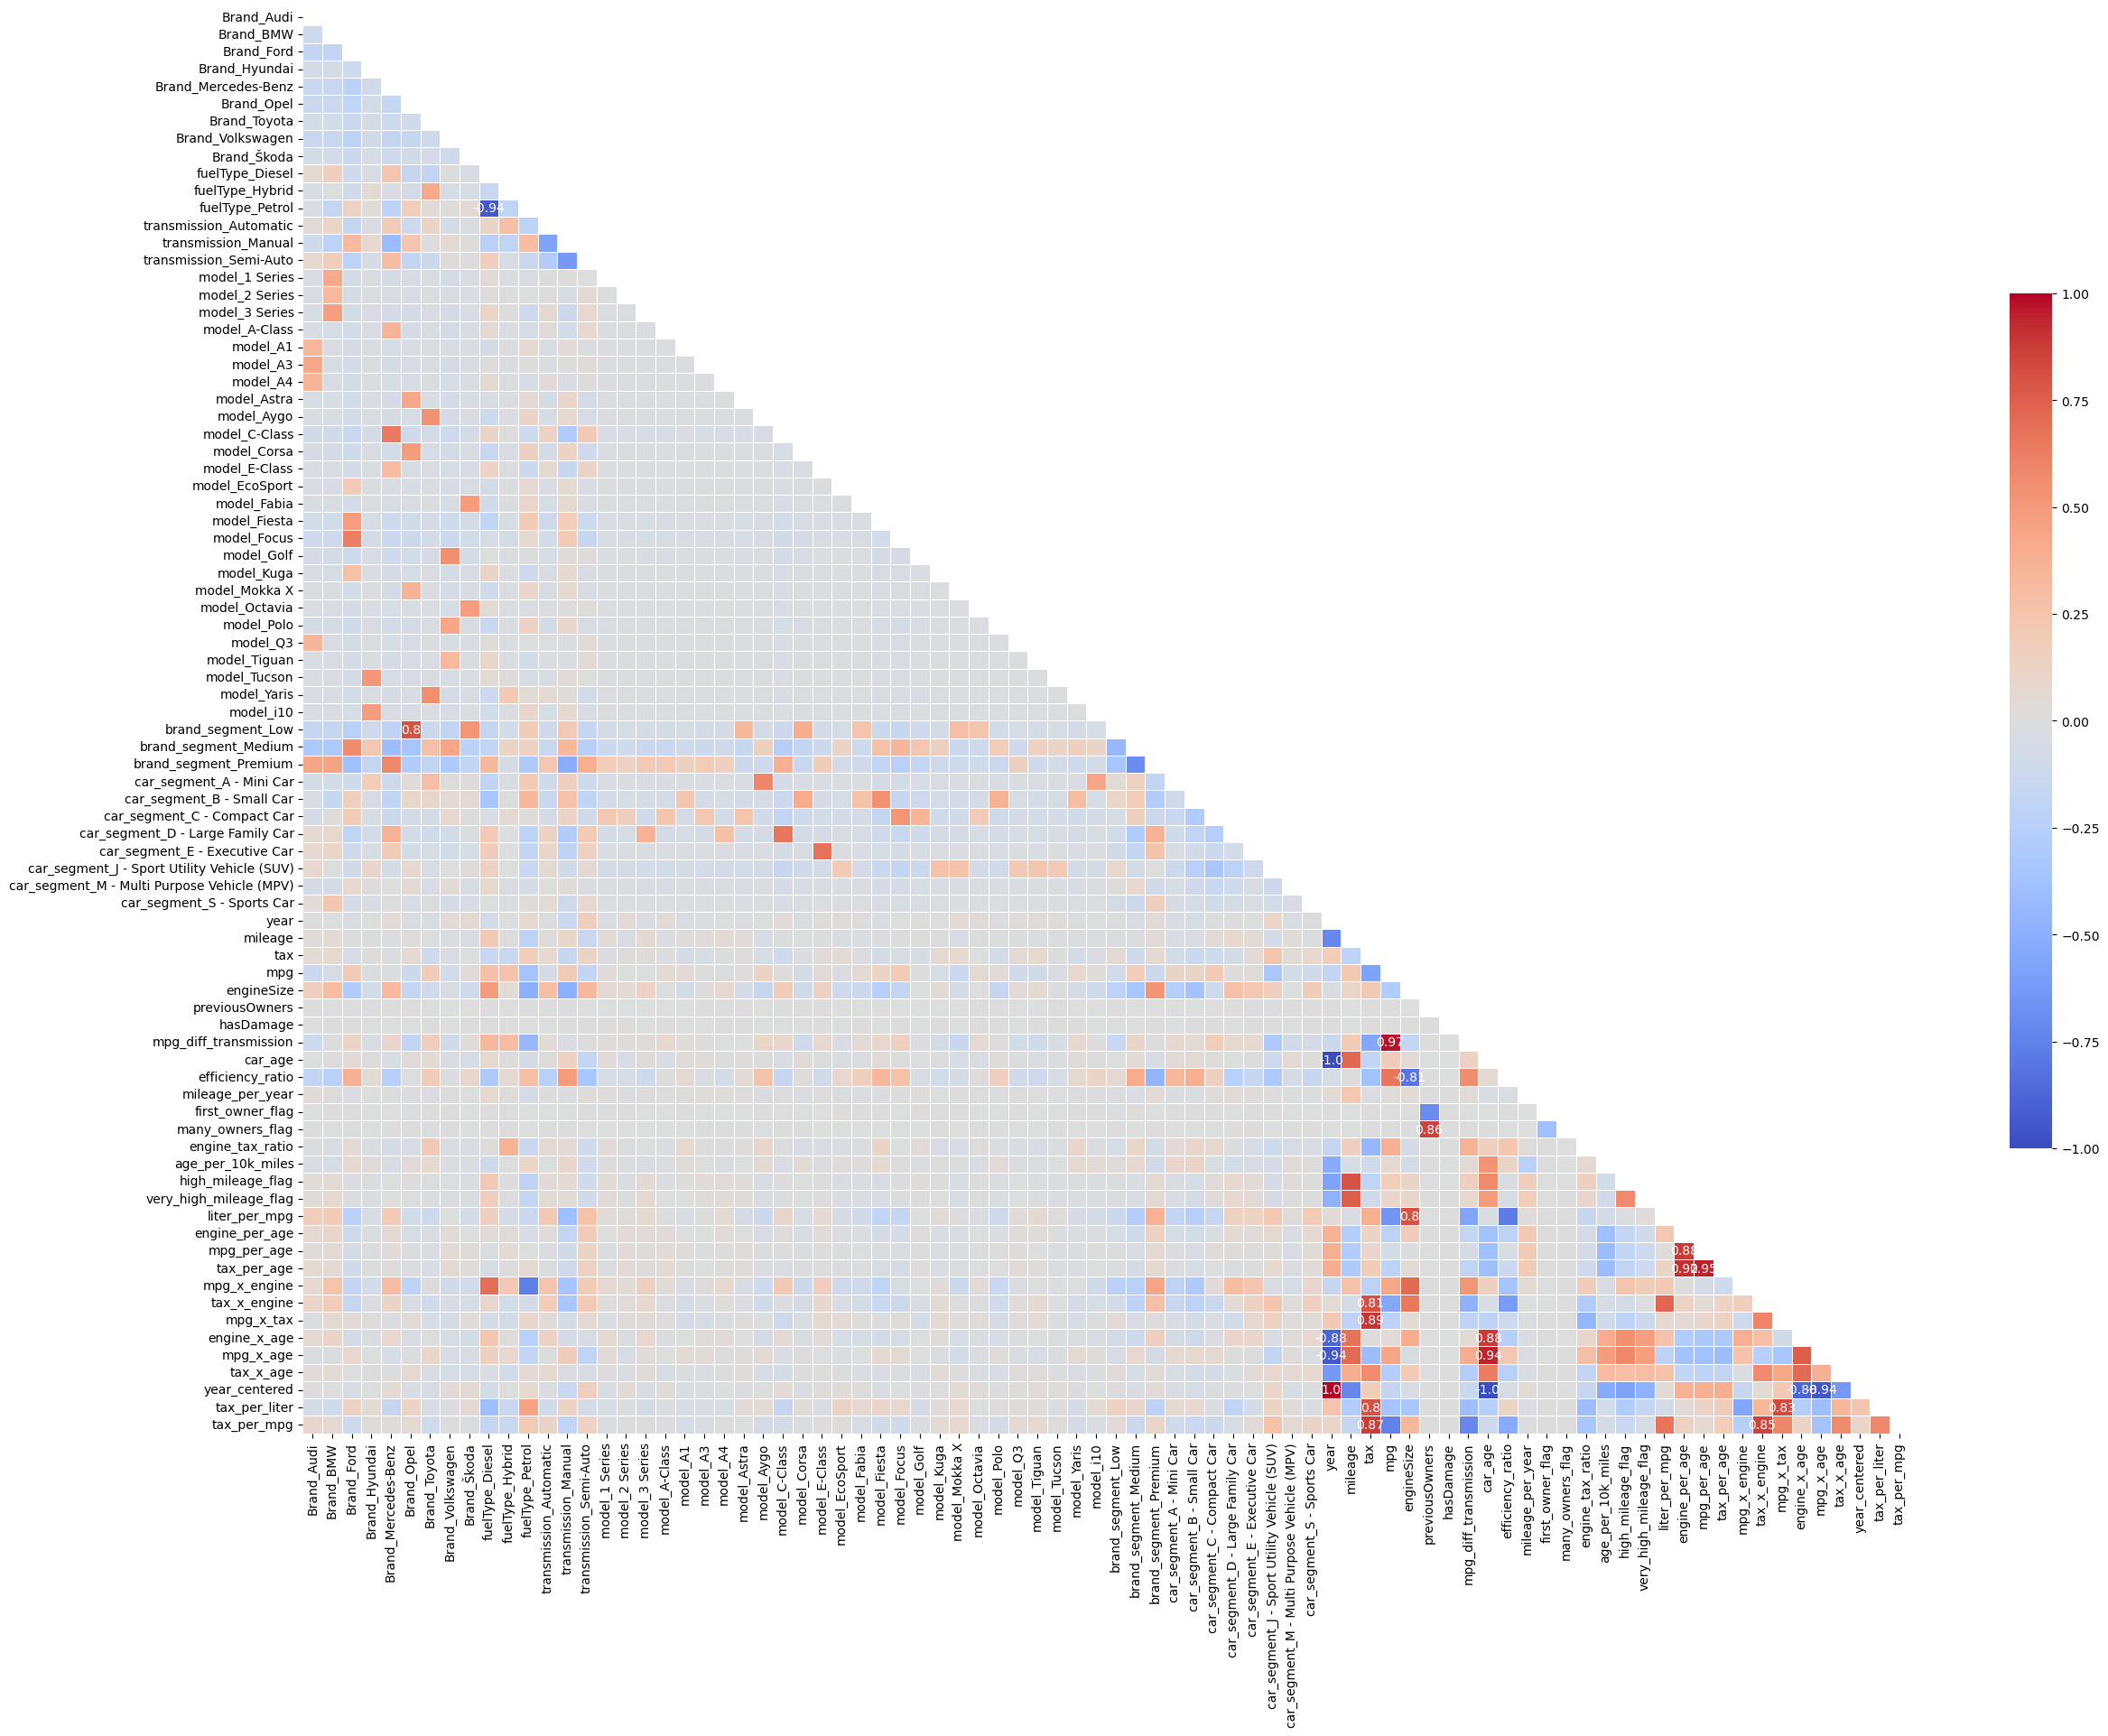

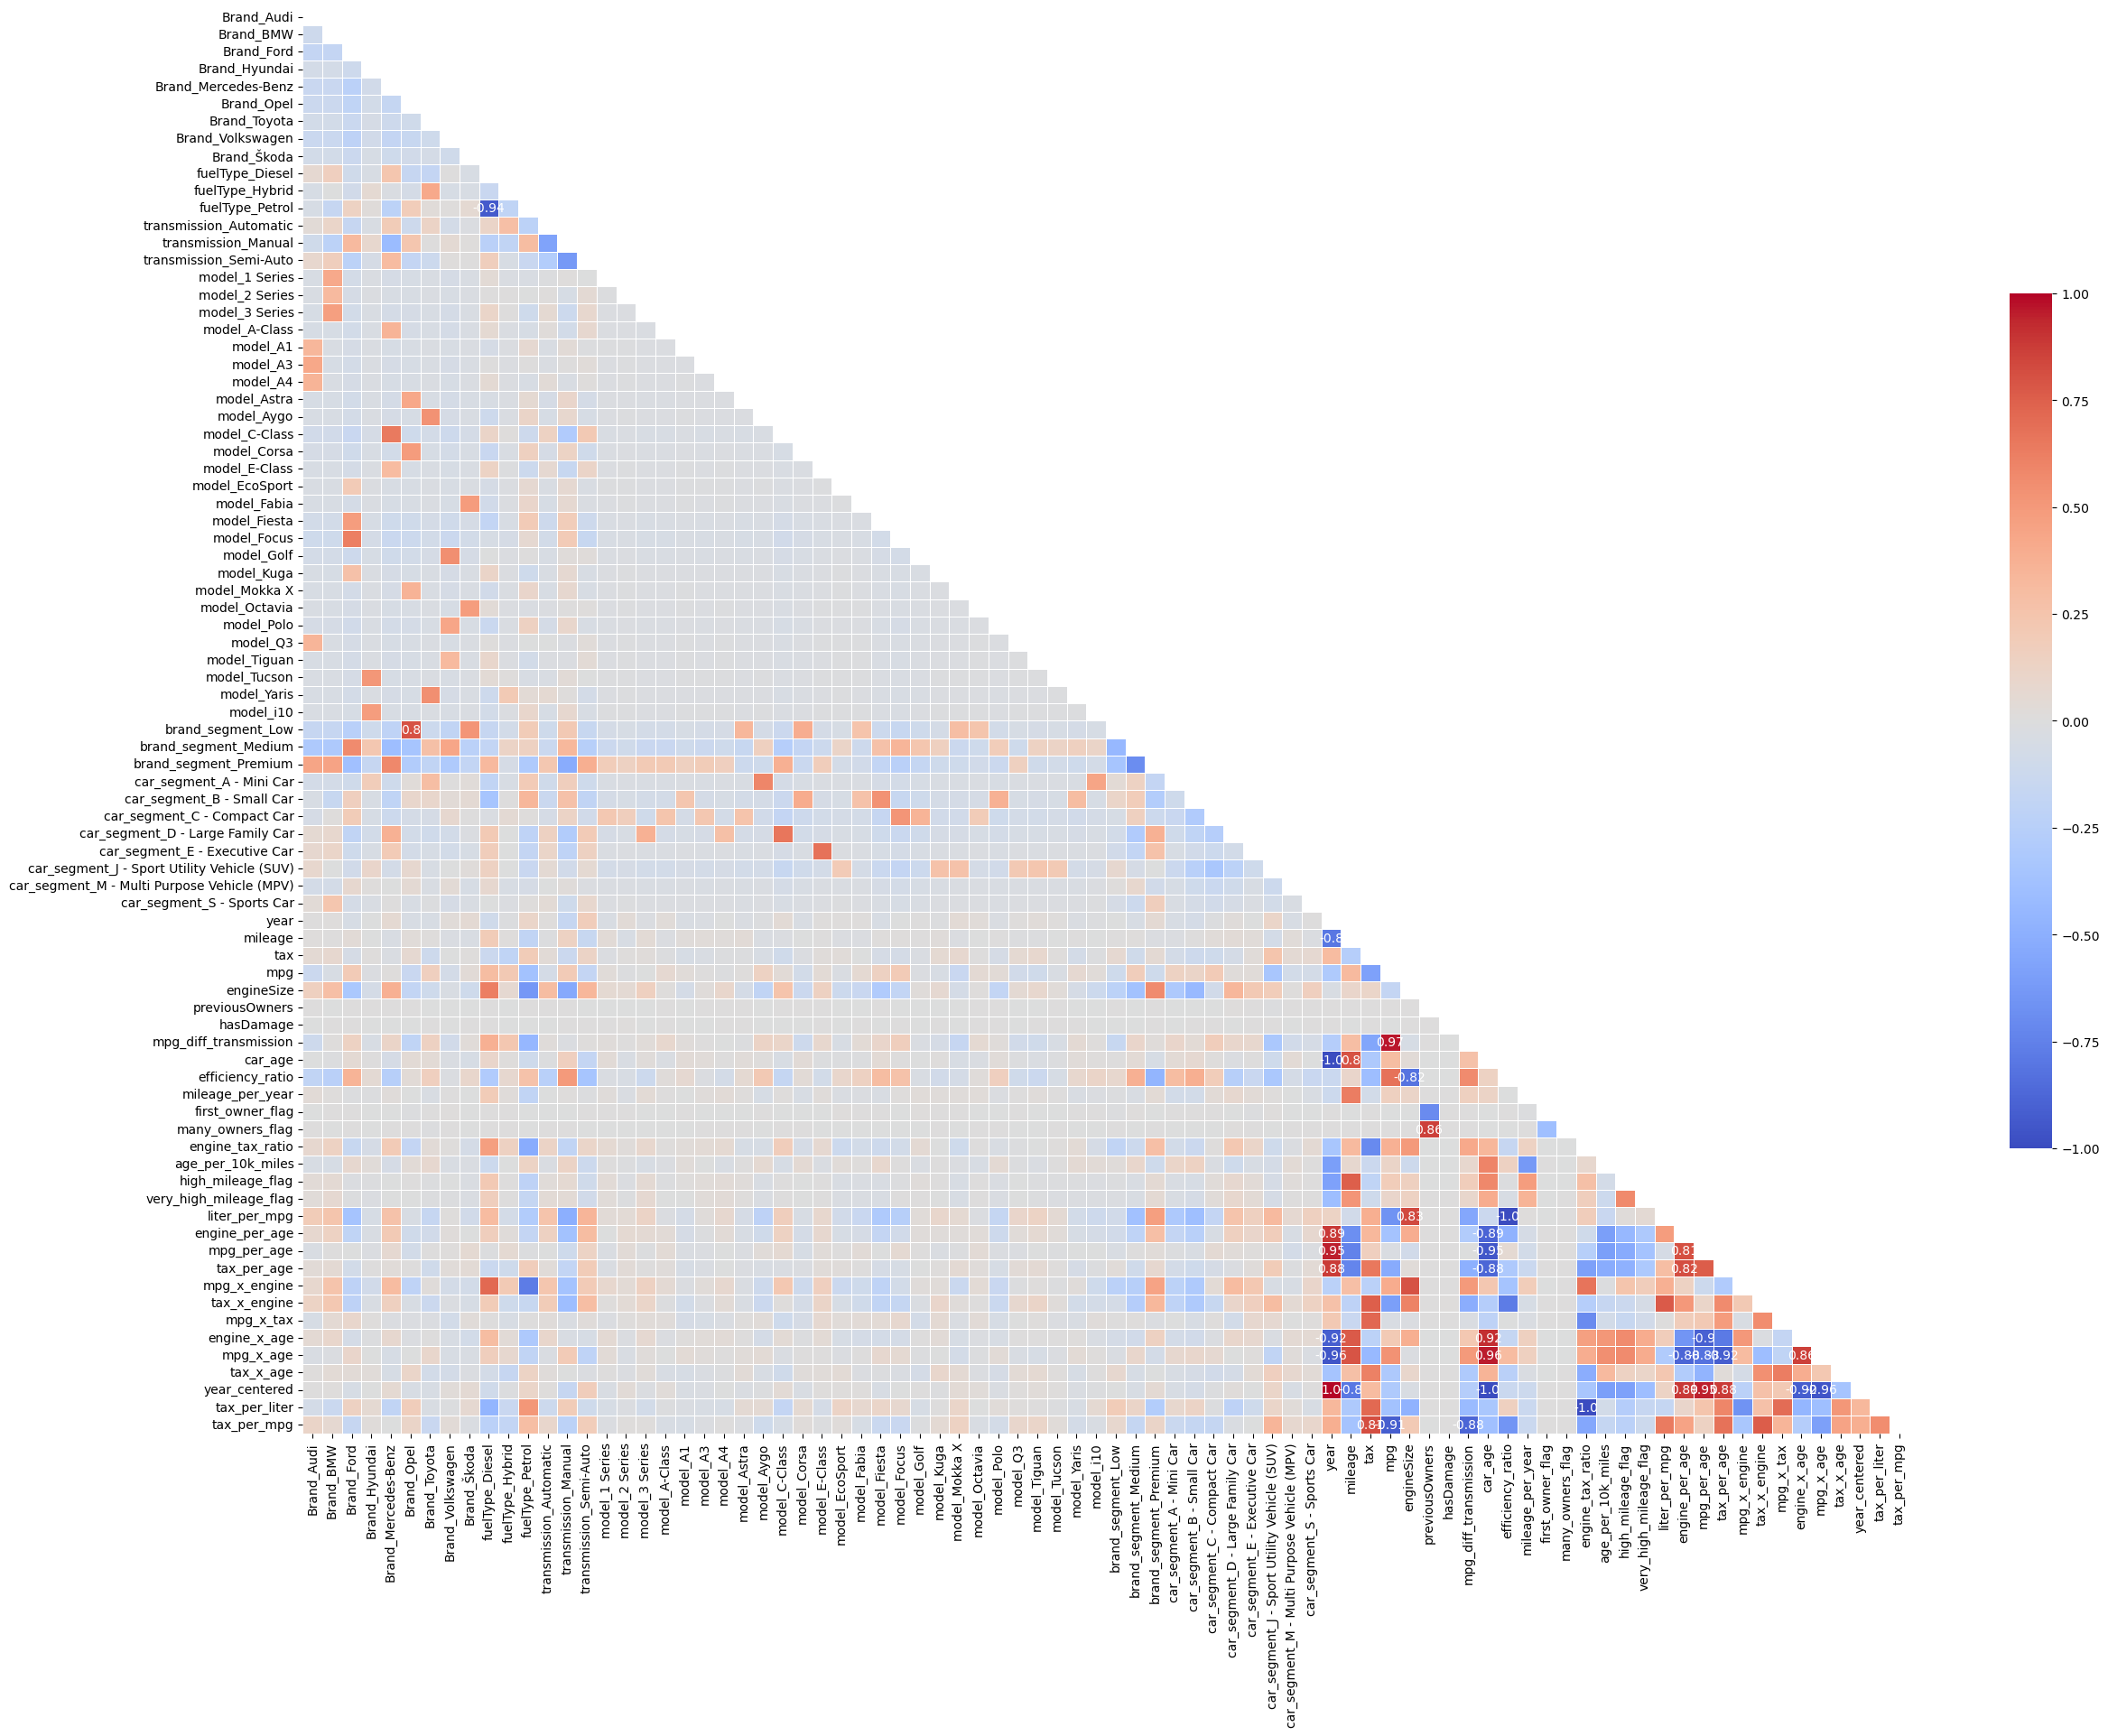

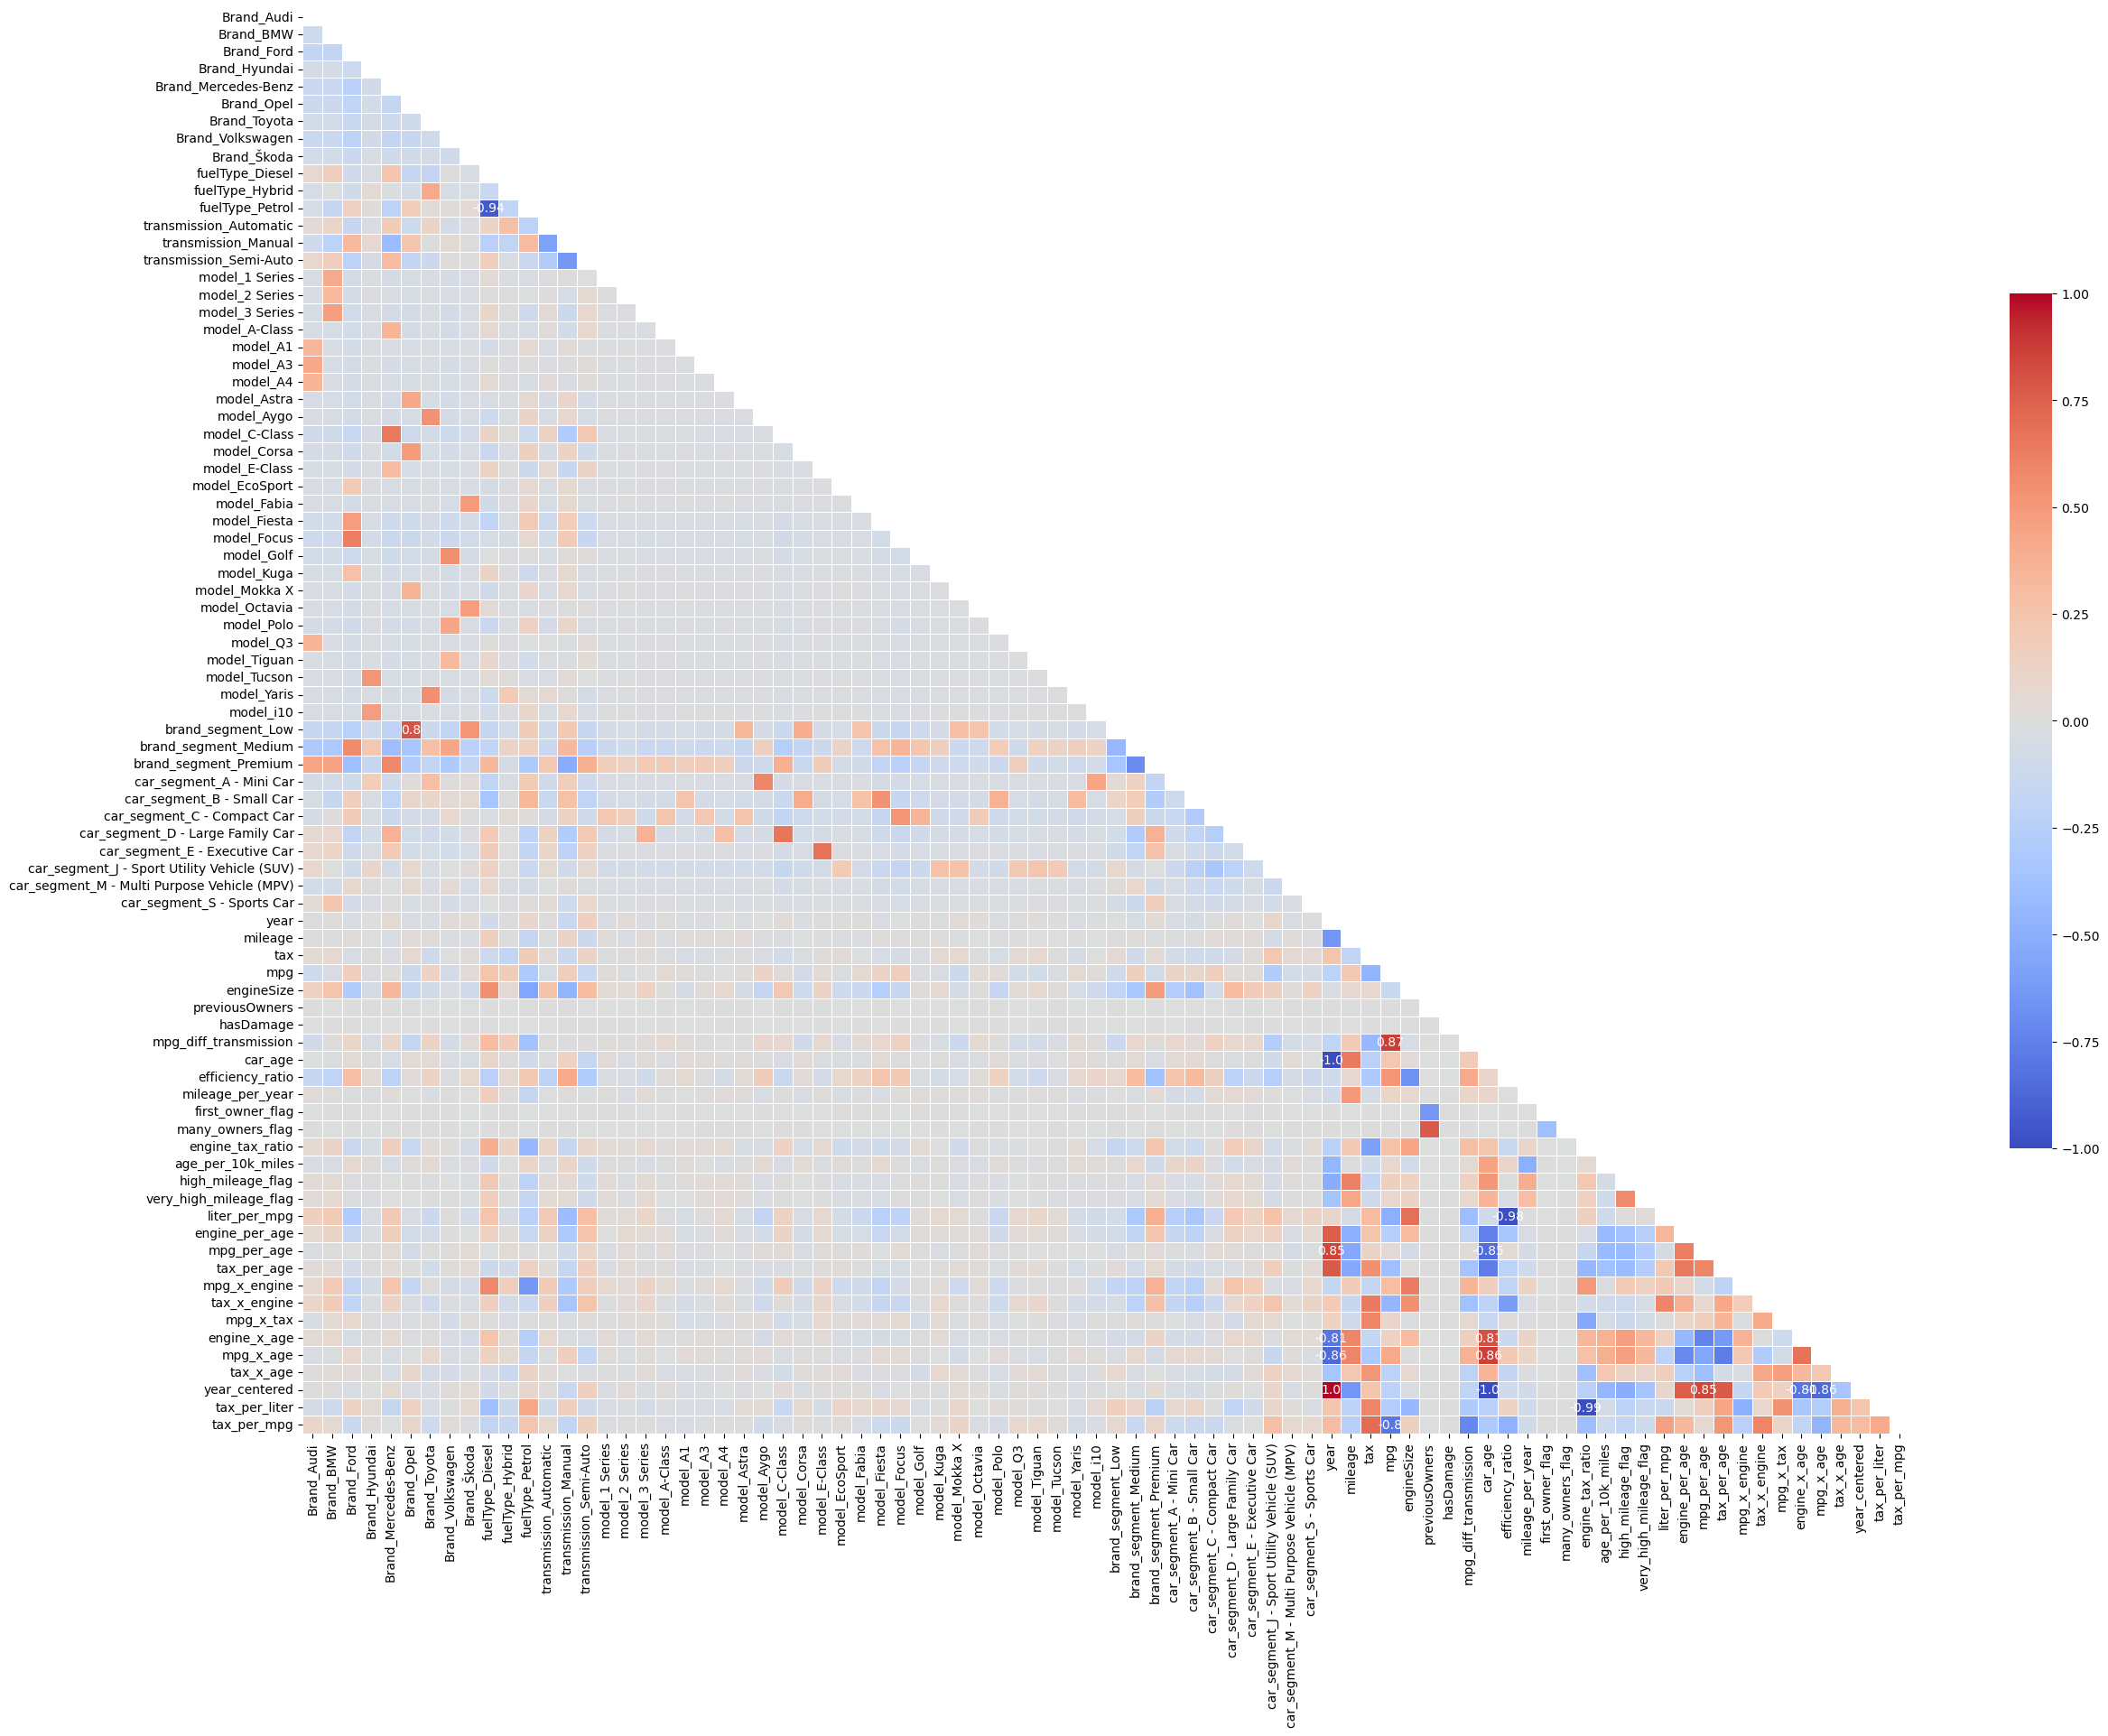

In [9]:
# Pearson, Spearman and Kendall Tau Correlation 
# Visualize feature-feature correlations (target excluded):
# - Pearson: linear relationships
# - Spearman/Kendall: monotonic relationships (rank-based)

methods = ["pearson", "spearman", "kendall"]
threshold = 0.8  # only show annotation when abs(corr) >= threshold

for method in methods:
    cor = x_train.corr(method=method)
    # boolean mask for the upper triangle
    mask = np.triu(np.ones_like(cor, dtype=bool))

    # Create annotation matrix: show numbers only where abs(cor) >= threshold, else empty string
    # round to 2 decimals and convert to strings
    annot_strings = cor.round(2).astype(str)
    annot_matrix = np.where(np.abs(cor) >= threshold, annot_strings, "")
    # ensure upper triangle annotations are empty
    annot_matrix = np.where(mask, "", annot_matrix)

    # optional: scale figure by number of features so labels don't overlap
    n = cor.shape[0]
    figsize = (max(10, n*0.35), max(8, n*0.25))

    plt.figure(figsize=figsize)
    sns.heatmap(
        cor,
        annot=annot_matrix,
        fmt="",              # fmt ignored when annot contains strings
        cmap="coolwarm",
        mask=mask,
        vmin=-1, vmax=1,
        linewidths=0.5,
        cbar_kws={"shrink": 0.6}
    )



Summarize key correlations observed (strength, direction) and note any multicollinearity to address.

In [10]:
# If 2 out of 3 methods show high correlation (>0.9), drop one feature from the pair
def drop_highly_correlated_features(x, threshold=0.9):
    """Drop redundant features based on multi-metric correlation voting.
    If at least two of (Pearson, Spearman, Kendall) exceed `threshold`,
    arbitrarily drop the second feature to reduce multicollinearity.
    Returns the reduced frame and the set of dropped names.
    """
    to_drop = set()
    cor_matrices = {
        "pearson": x.corr(method="pearson"),
        "spearman": x.corr(method="spearman"),
        "kendall": x.corr(method="kendall")
    }
    
    for i in range(len(x.columns)):
        for j in range(i + 1, len(x.columns)):
            col1 = x.columns[i]
            col2 = x.columns[j]
            high_corr_count = sum(
                abs(cor_matrices[method].loc[col1, col2]) > threshold 
                for method in cor_matrices
            )
            if high_corr_count >= 2:
                to_drop.add(col2)  # Arbitrarily drop col2
    
    x = x.drop(columns=list(to_drop))
    return x, to_drop


<a id="sec-5-wrapper"></a>
## 5. Wrapper Methods


There are different types of Wrapper Methods, we will use Recursive Feature Elimination (RFE) in this case.

- Exhaustive Feature, Forward Feature Selection, Backward Feature Elimination: These methods are computationally expensive and not feasible for datasets with a large number of features.
- Recursive Feature Elimination (RFE): We will use this method because it is computationally efficient and can effectively identify the most relevant features by recursively eliminating the least important ones based on model performance.

<a id="sec-5-1-rfe"></a>
### 5.1 Recursive Feature Elimination (RFE)


We use RFE to find out the optimal number of features to select based on model performance (R² score).

In [13]:
%%time
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np

# 1) Random forest für RFECV: SERIELL (kein nested parallelism)
rf_for_rfecv = RandomForestRegressor(
    n_estimators=150,
    random_state=42,
    n_jobs=1,              # <-- wichtig: keine Parallelisierung hier
    max_features="sqrt"
)

rfecv = RFECV(
    estimator=rf_for_rfecv,
    step=max(1, x_train.shape[1] // 10),
    cv=KFold(5, shuffle=True, random_state=42),
    scoring="r2",
    n_jobs=1               # <-- wichtig: RFECV seriell
)
rfecv.fit(x_train, y_train)

best_feats = x_train.columns[rfecv.support_]

# 2) Finaler RF: darf parallel sein, weil außenrum nix parallel läuft
final_rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1              # <- wenn du ganz safe willst: auf 1 setzen
)
final_rf.fit(x_train[best_feats], y_train)

# 3) Permutation Importance: SERIELL, damit kein Pickling/Worker-Overhead
perm = permutation_importance(
    final_rf,
    x_val[best_feats],
    y_val,
    n_repeats=3,
    random_state=42,
    scoring="r2",
    n_jobs=1               # <-- wichtig: seriell
)

imp_mean = pd.Series(perm.importances_mean, index=best_feats).sort_values(ascending=False)
imp_std  = pd.Series(perm.importances_std,  index=best_feats)

perm_table = pd.DataFrame({
    "feature": imp_mean.index,
    "perm_importance_mean": imp_mean.values,
    "perm_importance_std": imp_std.loc[imp_mean.index].values
})

print("\nPermutation importance (top 20):")
print(perm_table.head(20))

n_feats = len(imp_mean)
threshold = imp_mean.quantile(0.15)

print(f"Model : n_features={n_feats}, threshold=q25={threshold:.6f}")

selected_feats = imp_mean[imp_mean >= threshold].index.tolist()
dropped_feats  = imp_mean[imp_mean <  threshold].index.tolist()

print("kept:", len(selected_feats), "dropped:", len(dropped_feats))
print("dropped features:", dropped_feats)

x_train = x_train[selected_feats]
x_val   = x_val[selected_feats]
x_test  = x_test[selected_feats]


Permutation importance (top 20):
                        feature  perm_importance_mean  perm_importance_std
0                engine_per_age              0.746290             0.009732
1                   mpg_per_age              0.200383             0.006760
2                    engineSize              0.184885             0.002734
3         brand_segment_Premium              0.064557             0.001374
4           transmission_Manual              0.050179             0.002041
5                     mpg_x_age              0.040222             0.001238
6                     mpg_x_tax              0.026001             0.000775
7                       mileage              0.021175             0.000871
8                   tax_per_age              0.017962             0.001059
9                 liter_per_mpg              0.014012             0.000482
10  car_segment_C - Compact Car              0.013070             0.000902
11          Brand_Mercedes-Benz              0.012222             

<a id="sec-6-export"></a>
## 6. Export Selected Data

Export the feature-selected datasets for downstream modeling (notebook 30):
- `20_x_train.csv`, `20_y_train.csv`
- `20_x_val.csv`, `20_y_val.csv`
- `20_x_test.csv`


In [48]:
x_train = x_train[selected_feats]
x_val   = x_val[selected_feats]
x_test  = x_test[selected_feats]

In [49]:
# Print number of columns of the new datasets (post-selection)
print(f"x_train shape after feature selection: {x_train.shape}")
print(f"x_val shape after feature selection:   {x_val.shape}")
print(f"x_test shape after feature selection:  {x_test.shape}")

x_train shape after feature selection: (63296, 69)
x_val shape after feature selection:   (11171, 69)
x_test shape after feature selection:  (32567, 69)


In [50]:
x_train = x_train.reset_index()
x_val = x_val.reset_index()
x_test = x_test.reset_index()

In [51]:
# Export the dataset with selected features only

# Get current date string
date_str = datetime.now().strftime("%Y%m%d_%H%M")

# Define output directory
output_dir = os.path.join(data_dir, f"feature_selection/{date_str}")
os.makedirs(output_dir, exist_ok=True)

# Save the processed datasets
print(f"Saving feature_selected data to {output_dir}...")


x_train.to_csv(os.path.join(output_dir, "20_x_train.csv"), index=True)
y_train.to_csv(os.path.join(output_dir, "20_y_train.csv"), index=True)
x_val.to_csv(os.path.join(output_dir, "20_x_val.csv"), index=True)
y_val.to_csv(os.path.join(output_dir, "20_y_val.csv"), index=True)
x_test.to_csv(os.path.join(output_dir, "20_x_test.csv"), index=True)

print ("Feature selected data saved successfully (x/y separated):")

Saving feature_selected data to ../data/feature_selection/20251209_0115...
Feature selected data saved successfully (x/y separated):


In [52]:
x_train.head()

,carID,engine_per_age,mpg_per_age,engineSize,brand_segment_Premium,transmission_Manual,mpg_x_age,mpg_x_tax,mileage,tax_per_age,...,model_Tiguan,year,year_centered,model_E-Class,model_Tucson,model_Corsa,model_Yaris,model_Focus,model_Fabia,model_Polo
0,22856,-0.149271,-0.258108,0.594253,-0.743108,0.872612,-0.672129,0.046777,-0.189750,-0.167282,...,-0.128615,0.435421,0.435421,-0.132558,-0.109947,-0.185792,-0.141183,3.089915,-0.121044,-0.173371
1,45294,-0.311040,-0.289511,-0.304333,1.345699,0.872612,0.902064,-1.883385,1.448969,-0.417155,...,-0.128615,-0.496950,-0.496950,-0.132558,-0.109947,-0.185792,-0.141183,-0.323633,-0.121044,-0.173371
2,68602,-0.344675,-0.312305,-1.202918,-0.743108,0.872612,0.614361,-1.510685,0.584642,-0.400091,...,-0.128615,-0.496950,-0.496950,-0.132558,-0.109947,-0.185792,-0.141183,-0.323633,-0.121044,5.767983
3,68442,-0.321516,-0.350810,0.594253,-0.743108,0.872612,1.949891,-1.466036,2.303509,-0.405686,...,-0.128615,-1.429320,-1.429320,-0.132558,-0.109947,-0.185792,-0.141183,-0.323633,-0.121044,-0.173371
4,58609,-0.060917,-0.005529,-0.484050,-0.743108,0.872612,-0.959015,0.270179,-0.722215,0.043974,...,-0.128615,0.901606,0.901606,-0.132558,-0.109947,-0.185792,-0.141183,-0.323633,-0.121044,-0.173371


In [41]:
# Add some Logging info for this feature selection run and save it into a log file in the same output directory
log_file = os.path.join(output_dir, "feature_selection_log.txt")
with open(log_file, "w") as f:
    f.write(f"Feature Selection Log - {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Optimum number of features: {nof}\n")
    f.write(f"Best validation R² score: {high_score:.6f}\n")
    f.write("Selected features:\n")
    for feature in best_feature_names:
        f.write(f" - {feature}\n")
print(f"Log file saved to {log_file}")


NameError: name 'nof' is not defined

<a id="sec-7-next"></a>
### Next Steps
In the next notebook, we will proceed to modeling and evaluation using the feature-selected datasets prepared here.

[Back to top](#top)
